In [2]:
import matplotlib.pyplot as plt
import torch

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
})

def plot_trajectory(C, ax, L=1, cmap='viridis'):
    for j in range(len(C)):
        ax[j].imshow(C[j], extent=[0,L,0,L], cmap=cmap)
        ax[j].set_aspect('equal')
        ax[j].set_xlim(0, L)
        ax[j].set_ylim(0, L)

def SRR(eigvals, eigfuncs):
    next_eigfuncs = eigfuncs[1:,:]
    prev_eigfuncs = eigfuncs[:-1,:]
    next_eigfuncs_pred = prev_eigfuncs * eigvals.view(1,-1)
    residual = 100 * (next_eigfuncs - next_eigfuncs_pred).abs().pow(2).sum(dim=0) 
    residual /= eigfuncs.abs().pow(2).sum(dim=0)
    return residual

## Spiraling waves equation 

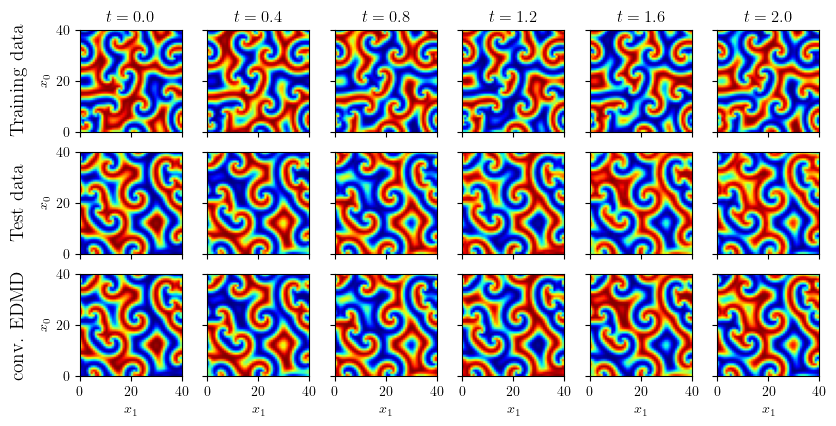

In [3]:
# spiral waves
L = 40
dt = 0.2
C_train = torch.load(f"data/spiralwaves_train.pt", weights_only=True)
C_pred = torch.load(f"generated data/spiralwaves_trajectory_pred.pt", weights_only=True)
C_test = torch.load(f"data/spiralwaves_test.pt", weights_only=True)

n_plots, n_steps = 6, 10
fig, ax = plt.subplots(3, n_plots, figsize=(n_plots*1.6, 4.5), sharey=True, sharex=True)

I = torch.linspace(0, n_steps, n_plots).long()
plot_trajectory(C_train[I,0], ax[0], L=L, cmap="jet")
plot_trajectory(C_pred[I,0], ax[1], L=L, cmap="jet")
plot_trajectory(C_test[I,0], ax[2], L=L, cmap="jet")
for i in range(n_plots): ax[0,i].set_title(f"$t = {I[i]*dt:.1f}$")
ax[0,0].text(-L*0.6, L/2, "Training data", rotation=90, fontsize=14, va='center', ha='center')
ax[1,0].text(-L*0.6, L/2, "Test data", rotation=90, fontsize=14, va='center', ha='center')
ax[2,0].text(-L*0.6, L/2, "conv. EDMD", rotation=90, fontsize=14, va='center', ha='center')
ax[0,0].set_ylabel("$x_0$")
ax[1,0].set_ylabel("$x_0$")
ax[2,0].set_ylabel("$x_0$")
for i in range(n_plots): ax[2,i].set_xlabel("$x_1$")

plt.savefig("plots/spiralwaves_comparison.pdf", bbox_inches='tight')
plt.show()

plotting 69120 eigenvalues
plotting 3000 eigenpairs


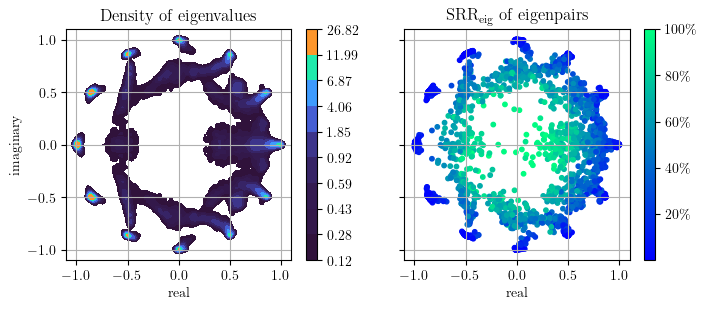

In [10]:
import seaborn as sns
import pandas as pd

eigvals_conv_all = torch.load(f"generated data/spiralwaves_eigvals_all.pt", weights_only=True)
eigvals_conv = torch.load(f"generated data/spiralwaves_eigvals.pt", weights_only=True)
eigfuncs_conv = torch.load(f"generated data/spiralwaves_eigfuncs.pt", weights_only=True)
print(f"plotting {eigvals_conv_all.shape[0]} eigenvalues")
print(f"plotting {eigvals_conv.shape[0]} eigenpairs")

residual_conv = SRR(eigvals_conv, eigfuncs_conv)

#region plotting eigenvalues
fig, ax = plt.subplots(1,2,figsize=(8,3), sharey=True)
eigvals_conv_all_df = pd.DataFrame(torch.stack((eigvals_conv_all.real, eigvals_conv_all.imag), dim=1).numpy(), columns=["real", "imaginary"])

sns.kdeplot( eigvals_conv_all_df, x="real", y="imaginary", fill=True, cmap="turbo", bw_adjust=0.15, ax=ax[0], cbar=True)
ax[0].set_xlim(-1.1, 1.1)
ax[0].set_ylim(-1.1, 1.1)
ax[0].grid()
ax[0].set_title("Density of eigenvalues")

plt.colorbar( plt.scatter( eigvals_conv.real, eigvals_conv.imag, c=residual_conv, s=10.0, cmap="winter", vmax=100 ), format="${x:.0f}\\%$" )
ax[1].set_xlim(-1.1, 1.1)
ax[1].set_ylim(-1.1, 1.1)
ax[1].grid()
ax[1].set_title("$\\mathrm{SRR}_{\\mathrm{eig}}$ of eigenpairs")
ax[1].set_xlabel("real")

plt.savefig("plots/spiralwaves_eigenvalues.pdf", bbox_inches='tight')
plt.show()
#endregion


## Kuramoto-Sivashinsky equation

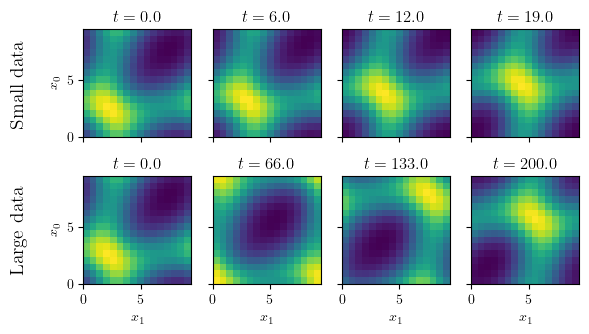

In [14]:
L = 3*torch.pi
dt = 1.0

C_train_large = torch.load(f"data/ks2d_large_data_train.pt", weights_only=True)
C_train_small = torch.load(f"data/ks2d_small_data_train.pt", weights_only=True)
C_test = torch.load(f"data/ks2d_small_data_train.pt", weights_only=True)

n_plots, n_steps = 4, 20
fig, ax = plt.subplots(2, n_plots, figsize=(n_plots*1.6, 3.5), sharey=True, sharex=True)

I_large = torch.linspace(0, len(C_train_large)-100, n_plots).long()
I_small = torch.linspace(0, len(C_train_small)-1, n_plots).long()
plot_trajectory(C_train_small[I_small,0], ax[0], L=L)
plot_trajectory(C_train_large[I_large,0], ax[1], L=L)

for i in range(n_plots): ax[0,i].set_title(f"$t = {I_small[i]*dt:.1f}$")
for i in range(n_plots): ax[1,i].set_title(f"$t = {I_large[i]*dt:.1f}$")
ax[1,0].text(-L*0.6, L/2, "Large data", rotation=90, fontsize=14, va='center', ha='center')
ax[0,0].text(-L*0.6, L/2, "Small data", rotation=90, fontsize=14, va='center', ha='center')
ax[1,0].set_ylabel("$x_0$")
ax[0,0].set_ylabel("$x_0$")
for i in range(n_plots): ax[1,i].set_xlabel("$x_1$")

plt.savefig("plots/ks2d_dataset_comparison.pdf", bbox_inches='tight')
plt.show()

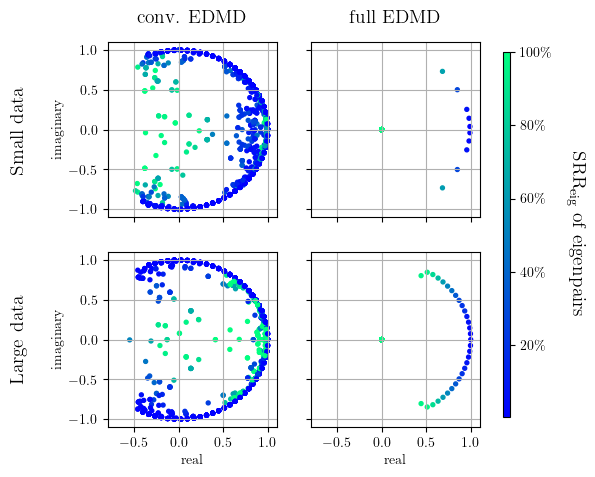

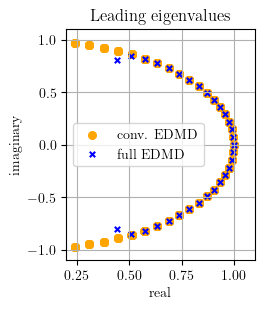

In [15]:
fig, ax = plt.subplots(2,2,figsize=(6,5), sharey=True, sharex=True)

for i, name, ds in zip([0,1], ["Small data", "Large data"], ["small_data", "large_data"]):

    eigvals_conv = torch.load(f"generated data/ks2d_{ds}_eigvals.pt", weights_only=True)
    eigfuncs_conv = torch.load(f"generated data/ks2d_{ds}_eigfuncs.pt", weights_only=True)
    eigvals_full = torch.load(f"generated data/ks2d_{ds}_full_edmd_eigvals.pt", weights_only=True)
    eigfuncs_full = torch.load(f"generated data/ks2d_{ds}_full_edmd_eigfuncs.pt", weights_only=True)

    residual_conv = SRR(eigvals_conv, eigfuncs_conv)
    residual_full = SRR(eigvals_full, eigfuncs_full)

    ax[i,0].scatter( eigvals_conv.real, eigvals_conv.imag, c=residual_conv, s=8.0, cmap="winter", vmax=100)
    ax[i,0].set_xlim(-0.8, 1.1)
    ax[i,0].set_ylim(-1.1, 1.1)
    ax[i,0].grid()
    # ax[i,0].set_aspect("equal")

    im = ax[i,1].scatter( eigvals_full.real, eigvals_full.imag, c=residual_full, s=8.0, cmap="winter", vmax=100 )
    ax[i,1].set_xlim(-0.8, 1.1)
    ax[i,1].set_ylim(-1.1, 1.1)
    ax[i,1].grid()
    # ax[i,1].set_aspect("equal")

ax[0,0].text(-1.8, 0, "Small data", rotation=90, fontsize=14, va='center', ha='center')
ax[1,0].text(-1.8, 0, "Large data", rotation=90, fontsize=14, va='center', ha='center')
ax[0,0].text(0.15, 1.4, "conv. EDMD", fontsize=14, va='center', ha='center')
ax[0,1].text(0.15, 1.4, "full EDMD", fontsize=14, va='center', ha='center')

ax[1,0].set_xlabel("real")
ax[1,1].set_xlabel("real")
ax[0,0].set_ylabel("imaginary")
ax[1,0].set_ylabel("imaginary")

cbar = plt.colorbar( im, ax=ax, shrink=0.95, aspect=50.0, format="${x:.0f}\\%$" )
cbar.ax.text(10, 50, "$\\mathrm{SRR}_{\\mathrm{eig}}$ of eigenpairs", rotation=-90, fontsize=14, va='center', ha='center')

plt.savefig("plots/ks2d_eigenvalues.pdf", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1,1,figsize=(3,3))
eigvals_conv_large = eigvals_conv[eigvals_conv.abs() > 0.999]
ax.scatter( eigvals_conv_large.real, eigvals_conv_large.imag, s=30.0, marker="o", color="orange", label="conv. EDMD")
ax.scatter( eigvals_full.real, eigvals_full.imag, s=15.0, marker="x", color="blue", label="full EDMD")
ax.set_xlim(0.2, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.grid()
ax.set_xlabel("real")
ax.set_ylabel("imaginary")
ax.set_title("Leading eigenvalues")
ax.legend()
ax.set_aspect(0.5)

plt.savefig("plots/ks2d_eigenvalues_alignment.pdf", bbox_inches='tight')
plt.show()


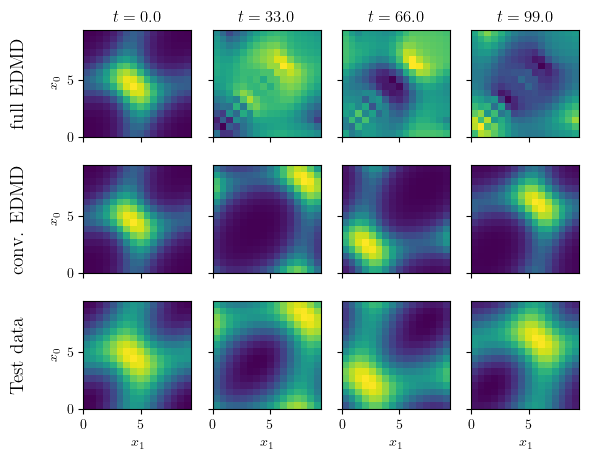

In [19]:
# C_pred_full = torch.load(f"./ks2d_large_data_full_edmd_trajectory_pred.pt", weights_only=True)
# C_pred = torch.load(f"./ks2d_large_data_trajectory_pred.pt", weights_only=True)
# C_test = torch.load(f"./ks2d_large_data_trajectory_test.pt", weights_only=True)
C_pred_full = torch.load(f"generated data/ks2d_small_data_full_edmd_trajectory_pred.pt", weights_only=True)
C_pred = torch.load(f"generated data/ks2d_small_data_trajectory_pred.pt", weights_only=True)
C_test = torch.load(f"generated data/ks2d_small_data_trajectory_test.pt", weights_only=True)

n_pred = len(C_test)-1

fig, ax = plt.subplots(3, n_plots, figsize=(n_plots*1.6, 5), sharey=True, sharex=True)
I = torch.linspace(0, n_pred, n_plots).long()
plot_trajectory(C_pred_full[I,0], ax[0], L=L)
plot_trajectory(C_pred[I,0], ax[1], L=L)
plot_trajectory(C_test[I,0], ax[2], L=L)
for i in range(n_plots): ax[0,i].set_title(f"$t = {I[i]*dt:.1f}$")
ax[0,0].text(-L*0.6, L/2, "full EDMD", rotation=90, fontsize=14, va='center', ha='center')
ax[1,0].text(-L*0.6, L/2, "conv. EDMD", rotation=90, fontsize=14, va='center', ha='center')
ax[2,0].text(-L*0.6, L/2, "Test data", rotation=90, fontsize=14, va='center', ha='center')
ax[0,0].set_ylabel("$x_0$")
ax[1,0].set_ylabel("$x_0$")
ax[2,0].set_ylabel("$x_0$")
for i in range(n_plots): ax[2,i].set_xlabel("$x_1$")

plt.savefig("plots/ks2d_trajectories_comparison.pdf", bbox_inches='tight')
plt.show()